**Initialize**

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols = ['time', 'long', 'x', 'y', 'z']
r_h = pd.read_csv('HEKTOR.aei', sep='\s+', skiprows=4, names=cols)
r_j = pd.read_csv('JUPITER.aei', sep='\s+', skiprows=4, names=cols)

**ICRF**

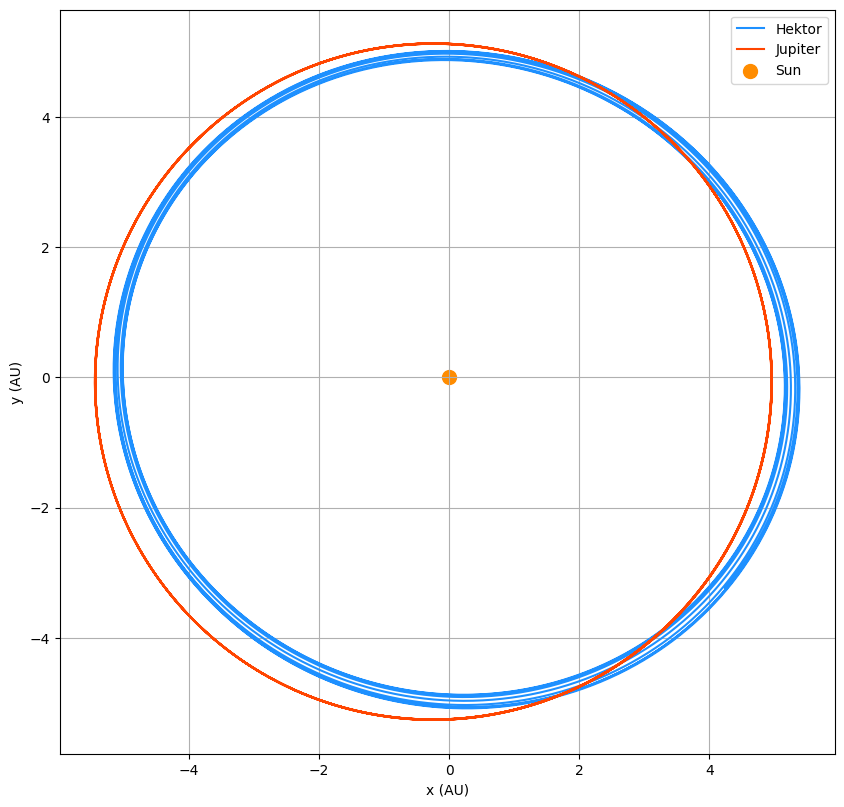

In [5]:
plt.figure(figsize=(10, 10))

plt.plot(r_h['x'], r_h['y'], label='Hektor', color='dodgerblue')
plt.plot(r_j['x'], r_j['y'], label='Jupiter', color='orangered')
plt.scatter([0], [0], color='darkorange', s=100, label='Sun')

plt.gca().set_aspect('equal')
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.legend()
plt.grid(True)
plt.show()

**Jupiter-centric coordinates**

In [10]:
theta = np.arctan2(r_j['y'], r_j['x'])

x_rot_h = r_h['x'] * np.cos(theta) + r_h['y'] * np.sin(theta) - (r_j['x'] * np.cos(theta) + r_j['y'] * np.sin(theta))
y_rot_h = -r_h['x'] * np.sin(theta) + r_h['y'] * np.cos(theta) - (-r_j['x'] * np.sin(theta) + r_j['y'] * np.cos(theta))

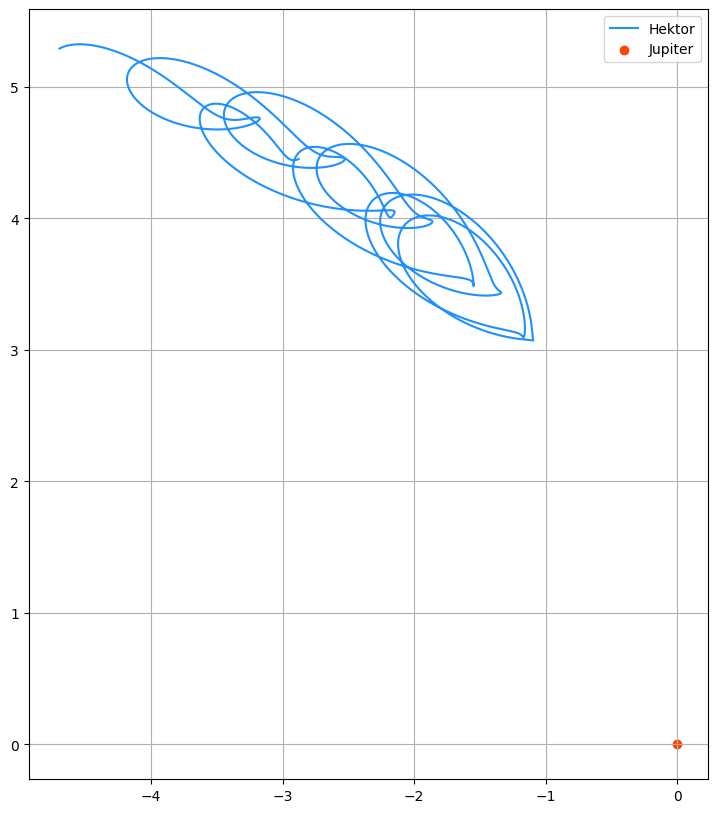

In [11]:
plt.figure(figsize=(10, 10))

plt.plot(x_rot_h, y_rot_h, label='Hektor', color='dodgerblue')
plt.scatter(0, 0, label='Jupiter', color='orangered')

plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True)
plt.show()

**HORIZONS Data**

In [ ]:
from astroquery.jplhorizons import Horizons
from astropy.time import Time

from astroquery.jplhorizons import Horizons
from astropy.time import Time

start_jd = 2458400.5
duration_yrs = 5
stop_jd = start_jd + (duration_yrs * 365.25)

start_iso = Time(start_jd, format='jd').iso.split()[0]
stop_iso = Time(stop_jd, format='jd').iso.split()[0]

epochs = {
    'start': start_iso,
    'stop': stop_iso,
    'step': '100d'
}

obj_h = Horizons(id='Hektor', location='@sun', epochs=epochs)
vec_h = obj_h.vectors()

obj_j = Horizons(id='5', location='@sun', epochs=epochs)
vec_j = obj_j.vectors()

x_h_real, y_h_real = np.array(vec_h['x']), np.array(vec_h['y'])
x_j_real, y_j_real = np.array(vec_j['x']), np.array(vec_j['y'])

theta_real = np.arctan2(y_j_real, x_j_real)

x_h_real_rot = x_h_real * np.cos(theta_real) + y_h_real * np.sin(theta_real) - (x_j_real * np.cos(theta_real) + y_j_real * np.sin(theta_real))
y_h_real_rot = -x_h_real * np.sin(theta_real) + y_h_real * np.cos(theta_real) - (-x_j_real * np.sin(theta_real) + y_j_real * np.cos(theta_real))

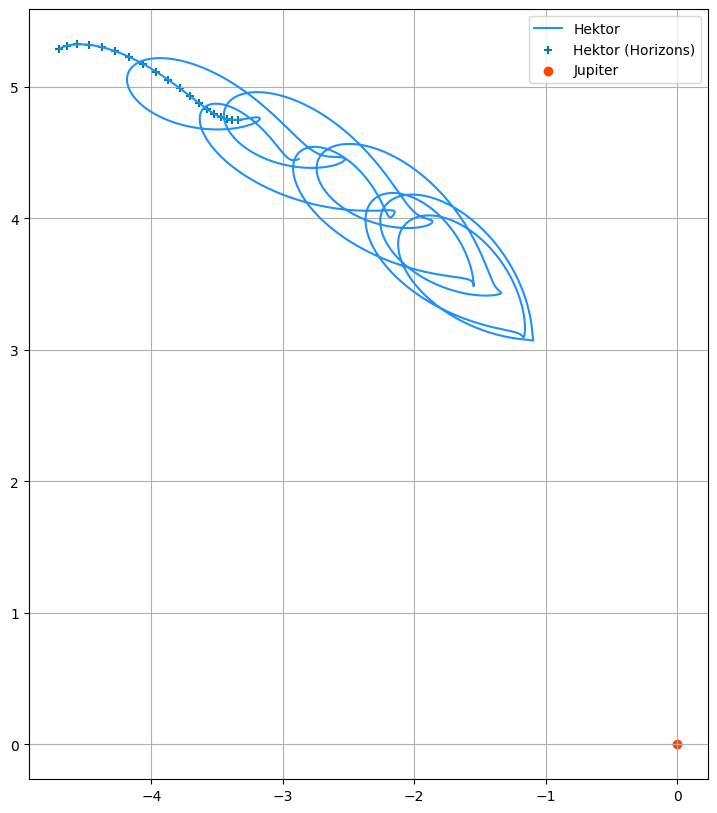

In [23]:
plt.figure(figsize=(10, 10))

plt.plot(x_rot_h, y_rot_h, label='Hektor', color='dodgerblue')
plt.scatter(x_h_real_rot, y_h_real_rot, label='Hektor (Horizons)', color='teal', marker='+')
plt.scatter(0, 0, label='Jupiter', color='orangered')

plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True)
plt.show()